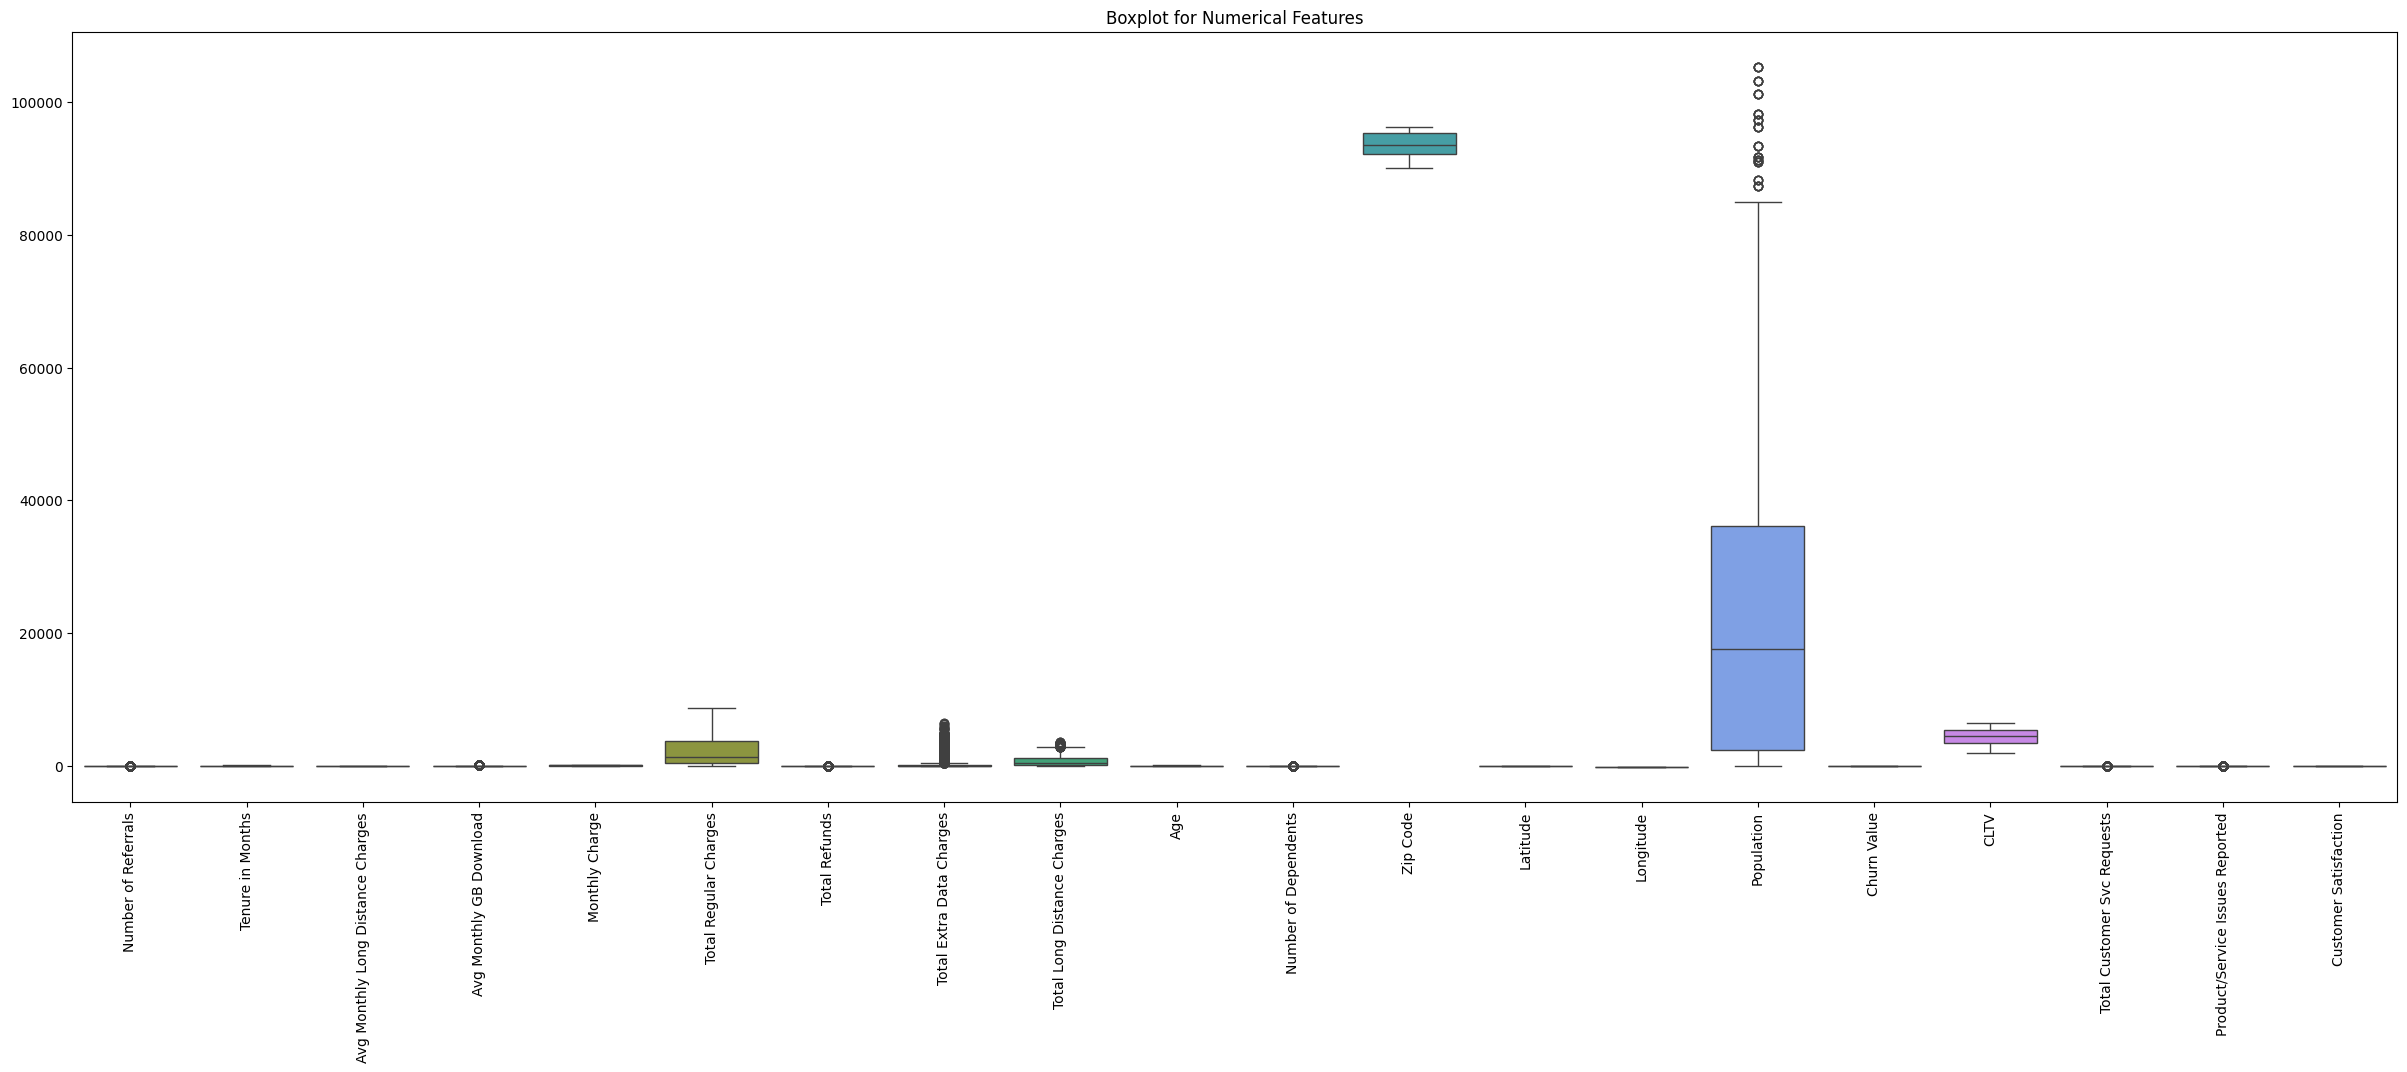

,Customer ID,Referred a Friend,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Service,Internet Type,...,Latitude,Longitude,Population,Churn Value,CLTV,Churn Category,Churn Reason,Total Customer Svc Requests,Product/Service Issues Reported,Customer Satisfaction
0,8779-QRDMV,No,0,1,<NA>,No,0.00,No,Yes,Fiber Optic,...,34.023810,-118.156582,68701,1,5433,Competitor,Competitor offered more data,5,0,NaN
1,7495-OOKFY,Yes,1,8,Offer E,Yes,48.85,Yes,Yes,Cable,...,34.044271,-118.185237,55668,1,5302,Competitor,Competitor made better offer,5,0,NaN
2,1658-BYGOY,No,0,18,Offer D,Yes,11.33,Yes,Yes,Fiber Optic,...,34.108833,-118.229715,47534,1,3179,Competitor,Competitor made better offer,1,0,NaN
3,4598-XLKNJ,Yes,1,25,Offer C,Yes,19.76,No,Yes,Fiber Optic,...,33.936291,-118.332639,27778,1,5337,Dissatisfaction,Limited range of services,1,1,2.0
4,4846-WHAFZ,Yes,1,37,Offer C,Yes,6.33,Yes,Yes,Cable,...,33.972119,-118.020188,26265,1,2793,Price,Extra data charges,1,0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2569-WGERO,No,0,72,<NA>,Yes,22.77,No,No,<NA>,...,34.341737,-116.539416,2182,0,5306,<NA>,<NA>,0,0,NaN
7039,6840-RESVB,Yes,1,24,Offer C,Yes,36.05,Yes,Yes,DSL,...,34.667815,-117.536183,18980,0,2140,<NA>,<NA>,2,0,NaN
7040,2234-XADUH,Yes,4,72,<NA>,Yes,29.66,Yes,Yes,Cable,...,34.559882,-115.637164,42,0,5560,<NA>,<NA>,2,0,4.0
7041,4801-JZAZL,Yes,1,11,<NA>,No,0.00,No,Yes,DSL,...,34.167800,-116.864330,301,0,2793,<NA>,<NA>,0,0,NaN


In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

data_df = pd.read_csv(r'Theme 2.csv')

# dealing with nan values
data_df = data_df.fillna(pd.NA)

# drop duplicate rows
clean_df = data_df.drop_duplicates()

# outlier detection using boxplot
plt.figure(figsize=(30, 10))
plt.xticks(rotation=90)
sns.boxplot(data=clean_df.select_dtypes(include=['number']))
plt.title('Boxplot for Numerical Features')
plt.show()

clean_df.to_csv('cleaned_theme_2.csv', index=False)
display(clean_df)

### EDA ###

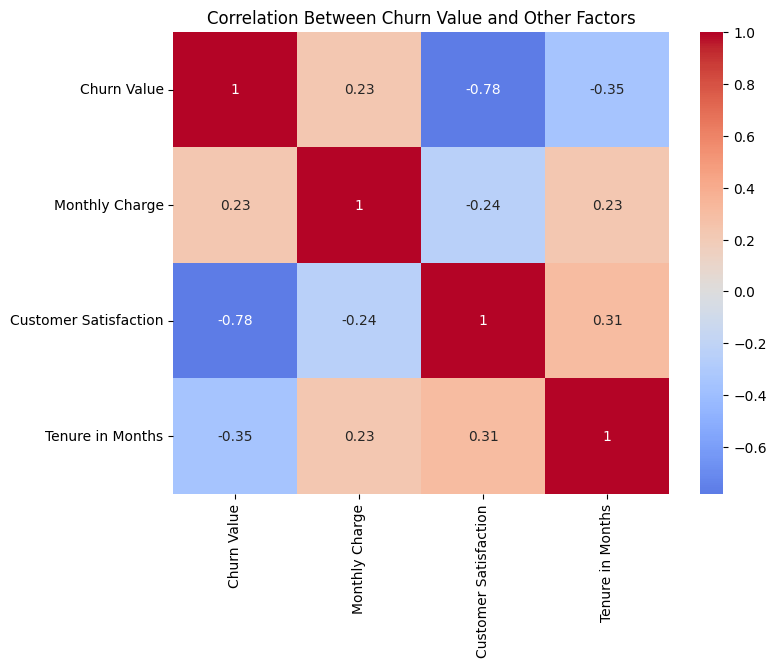

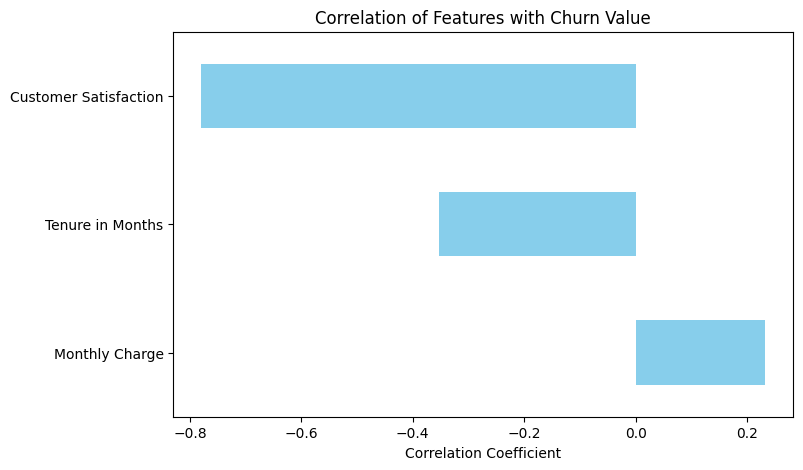

In [67]:
# correlation heatmap
cols_to_correlate = ['Churn Value', 'Monthly Charge', 'Customer Satisfaction', 'Tenure in Months']
corr_df = data_df[cols_to_correlate]
corr_matrix = corr_df.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Between Churn Value and Other Factors')
plt.show()

churn_corr = corr_matrix['Churn Value'].sort_values(ascending=False)
churn_corr.drop('Churn Value').plot(kind='barh', figsize=(8,5), color='skyblue')
plt.title('Correlation of Features with Churn Value')
plt.xlabel('Correlation Coefficient')
plt.show()

### Quantitative questions ###

In [68]:
# q1: what is the median tenure of churned customers and the median tenure of non-churned customers?
churned_df = clean_df[clean_df['Churn Value']==1]
non_churned_df = clean_df[clean_df['Churn Value']==0]

median_tenure_churned = churned_df['Tenure in Months'].median()
median_tenure_non_churned = non_churned_df['Tenure in Months'].median()

print("Median Tenure of Churned Customers:", median_tenure_churned)
print("Median Tenure of Non-Churned Customers:", median_tenure_non_churned)


Median Tenure of Churned Customers: 10.0
Median Tenure of Non-Churned Customers: 38.0


In [69]:
# q2: what are the top 5 countries with the highest churn rates? what is the most common reason for churn for the 5 countries, respectively?
cities_by_churn_rate = churned_df['City'].groupby(data_df['Churn Value']).value_counts()
top_5_cities_by_churn_rate_df = pd.DataFrame(cities_by_churn_rate[1].nlargest(5)).reset_index()
display(top_5_cities_by_churn_rate_df)

print("Top 5 Cities by Churn Rate:", top_5_cities_by_churn_rate_df['City'].tolist())


for i in top_5_cities_by_churn_rate_df['City']:
    top_5_cities_data_df = churned_df[churned_df['City']==i] 
    top_5_cities_churn_reason_df = pd.DataFrame(top_5_cities_data_df['Churn Reason'].value_counts()).reset_index()
    display(top_5_cities_churn_reason_df)
    print(f"The most common reason for churn in {i} is: ", top_5_cities_churn_reason_df['Churn Reason'].iloc[0])

,City,count
0,San Diego,185
1,Los Angeles,78
2,San Francisco,31
3,San Jose,29
4,Fallbrook,26


Top 5 Cities by Churn Rate: ['San Diego', 'Los Angeles', 'San Francisco', 'San Jose', 'Fallbrook']


,Churn Reason,count
0,Competitor made better offer,146
1,Don't know,15
2,Attitude of support person,8
3,Competitor had better devices,6
4,Poor expertise of online support,2
5,Attitude of service provider,2
6,Product dissatisfaction,2
7,Long distance charges,2
8,Network reliability,1
9,Lack of self-service on Website,1


The most common reason for churn in San Diego is:  Competitor made better offer


,Churn Reason,count
0,Competitor had better devices,15
1,Competitor offered higher download speeds,9
2,Competitor offered more data,8
3,Don't know,7
4,Competitor made better offer,7
5,Extra data charges,6
6,Attitude of support person,5
7,Moved,3
8,Service dissatisfaction,3
9,Long distance charges,3


...

The most common reason for churn in San Francisco is:  Competitor had better devices


,Churn Reason,count
0,Competitor had better devices,7
1,Competitor offered more data,4
2,Moved,3
3,Competitor offered higher download speeds,3
4,Service dissatisfaction,2
5,Deceased,1
6,Attitude of support person,1
7,Don't know,1
8,Competitor made better offer,1
9,Network reliability,1


The most common reason for churn in San Jose is:  Competitor had better devices


,Churn Reason,count
0,Competitor made better offer,23
1,Don't know,2
2,Poor expertise of online support,1


The most common reason for churn in Fallbrook is:  Competitor made better offer


In [70]:
# q3: which consumer segments have the highest churn rates based on demographics, location or service usage?

# DEMOGRAPHIC #

# gender
gender_by_churn_rate_df = pd.DataFrame(churned_df['Gender'].groupby(clean_df['Churn Value']).value_counts()).reset_index()
display(gender_by_churn_rate_df)
print(f"The gender with the highest churn rate is {gender_by_churn_rate_df['Gender'].iloc[0]}")

# age
age_by_churn_rate_df = pd.DataFrame(churned_df['Age'].groupby(clean_df['Churn Value']).value_counts()).reset_index()
display(age_by_churn_rate_df)
print(f"The ages with the highest churn rates are {age_by_churn_rate_df['Age'].iloc[0:3].tolist()}")

# marriage status
married_by_churn_rate_df = pd.DataFrame(churned_df['Married'].groupby(clean_df['Churn Value']).value_counts()).reset_index()
marriage_status_dict = {'Yes':'Married', 'No':'Unmarried'}
married_by_churn_rate_df.replace({'Married':marriage_status_dict}, inplace=True)
display(married_by_churn_rate_df)
print(f"The marriage status with the highest churn rate is {married_by_churn_rate_df['Married'].iloc[0]}")


# LOCATION #
zipcode_by_churn_rate_df = pd.DataFrame(churned_df['Zip Code'].groupby(clean_df['Churn Value']).value_counts()).reset_index()
display(zipcode_by_churn_rate_df)
print(f"The zipcode area with the highest churn rate is {zipcode_by_churn_rate_df['Zip Code'].iloc[0]}")


# SERVICE USAGE #
phone_service_by_churn_rate_df = pd.DataFrame(churned_df['Phone Service'].groupby(clean_df['Churn Value']).value_counts()).reset_index()
internet_service_by_churn_rate_df = pd.DataFrame(churned_df['Internet Service'].groupby(clean_df['Churn Value']).value_counts()).reset_index()
display(phone_service_by_churn_rate_df)
display(internet_service_by_churn_rate_df)
if phone_service_by_churn_rate_df[phone_service_by_churn_rate_df['Phone Service']=='Yes'].iloc[0,1] >internet_service_by_churn_rate_df[internet_service_by_churn_rate_df['Internet Service']=='Yes'].iloc[0,1]:
    print("The service type with the highest churn rate is the phone service.")
else:
    print("The service type with the highest churn rate is the internet service.")

,Churn Value,Gender,count
0,1,Female,939
1,1,Male,930


The gender with the highest churn rate is Female


,Churn Value,Age,count
0,1,44,41
1,1,47,41
2,1,53,41
3,1,68,40
4,1,39,39
...,...,...,...
57,1,43,22
58,1,45,20
59,1,19,18
60,1,24,18


The ages with the highest churn rates are [44, 47, 53]


,Churn Value,Married,count
0,1,Unmarried,1200
1,1,Married,669


...

,Churn Value,Zip Code,count
0,1,92122,33
1,1,92117,30
2,1,92126,28
3,1,92028,26
4,1,92109,24
...,...,...,...
1109,1,96132,1
1110,1,96136,1
1111,1,96141,1
1112,1,96142,1


The zipcode area with the highest churn rate is 92122


,Churn Value,Phone Service,count
0,1,Yes,1699
1,1,No,170


,Churn Value,Internet Service,count
0,1,Yes,1756
1,1,No,113


The service type with the highest churn rate is the internet service.


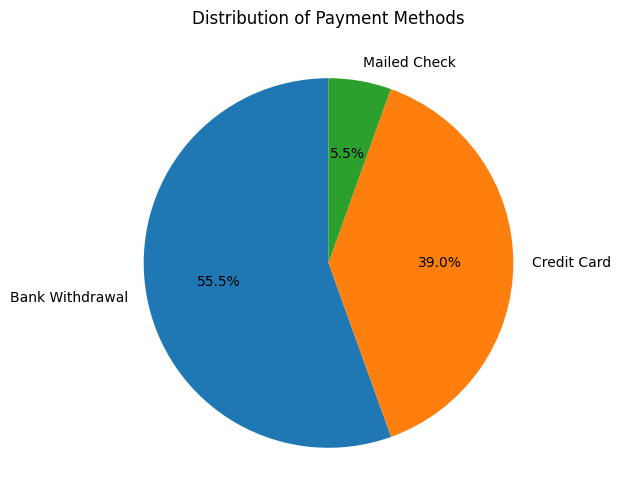

In [71]:
# q4: what are the distributions of payment methods adopted by customers?
payment_methods_df = pd.DataFrame(clean_df['Payment Method'].value_counts()).reset_index()
payment_methods_df.columns = ['Payment Method', 'Count']
plt.figure(figsize=(6, 6))
plt.pie(payment_methods_df['Count'], labels=payment_methods_df['Payment Method'], autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Payment Methods')
plt.show()